<div>

# **AI agent use Tavily**

<div dir=RTL>

# **התקנות / ספריות**

In [1]:
# התקנה
!pip install -q langgraph langchain-google-genai langchain-community tavily-python
# ספריות
import os
from google.colab import userdata
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_community.tools.tavily_search import TavilySearchResults

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.6/67.6 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 28.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 26.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 542.4/542.4 kB 21.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.9/64.9 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.0/51.0 kB 1.9 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.33.1 which is incompatible.


<div dir=RTL>

# **הגדרת מודל וכלים**

In [ ]:
# מפתחות
os.environ["GOOGLE_API_KEY"] = userdata.get("GOOGLE_API_KEY")
os.environ["TAVILY_API_KEY"] = userdata.get("TAVILY_API_KEY")

# כלים
tools = [TavilySearchResults(max_results=3)]

# מודל
model = ChatGoogleGenerativeAI(
    model="gemini-pro-latest",
    google_api_key=os.environ["GOOGLE_API_KEY"]
).bind_tools(tools)

<div dir=RTL>

# **הגדרת גרף**

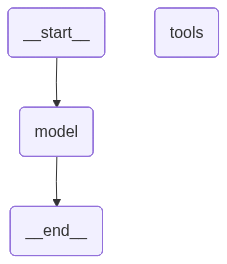

In [3]:
from langgraph.graph import StateGraph, MessagesState, START, END
from langgraph.prebuilt import ToolNode

# צומת המודל
def call_model(state: MessagesState):
    return {"messages": [model.invoke(state["messages"])]}

# בדיקה: האם המודל ביקש להפעיל כלי?
def should_continue(state: MessagesState):
    return "tools" if state["messages"][-1].tool_calls else END

# בניית הגרף
graph = StateGraph(MessagesState)
graph.add_node("model", call_model)
graph.add_node("tools", ToolNode(tools))

graph.add_edge(START, "model")
graph.add_conditional_edges("model", should_continue)
graph.add_edge("tools", "model")

agent = graph.compile()

# הצגת הגרף
from IPython.display import Image, display
display(Image(agent.get_graph().draw_mermaid_png()))

<div dir=RTL>

# **הפעלת סוכן**

In [ ]:
from langchain_core.messages import HumanMessage

# שאל את הסוכן שאלה
question = "מה החדשות הכי מעניינות בתחום ה-AI היום?"

collected_messages = []
for s in agent.stream({"messages": [HumanMessage(content=question)]}):
    # LangGraph's stream often yields dictionary where keys are node names
    # and values are the output of that node. We need to check these values.
    # The 'messages' are usually nested.

    # Check if 'model' node output messages
    if "model" in s and isinstance(s["model"], dict) and "messages" in s["model"]:
        collected_messages.extend(s["model"]["messages"])
    # Check if 'tools' node output messages (if applicable for debugging/tracing tool calls)
    elif "tools" in s and isinstance(s["tools"], dict) and "messages" in s["tools"]:
        collected_messages.extend(s["tools"]["messages"])
    # If the state itself contains messages (e.g., final state update might just have 'messages')
    elif "messages" in s:
        collected_messages.extend(s["messages"])

result = {"messages": collected_messages}

<div dir=RTL>

# **הדפסת התשובה**

In [ ]:
# הדפסת תשובה
print(result["messages"][-1].content)